In [1]:
# Personalized Retail Recommendation Agent — EDA, Preprocessing & Model

# This notebook walks through the analysis behind the recommendation agent, in the order it was actually done:

# 1. Load and inspect the dataset
# 2. Exploratory data analysis (EDA)
# 3. Key finding: why classic collaborative filtering doesn't apply here
# 4. Correlation analysis (why the propensity model performs the way it does)
# 5. Preprocessing
# 6. Model training — `RandomForestClassifier`
# 7. Honest evaluation

# Update the `DATA_PATH` variable in the next cell if your CSV is somewhere other than the same folder as this notebook.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

DATA_PATH = "retail_personalization_dataset.csv"  # change if needed


In [ ]:
# 1. Load and inspect the dataset

In [3]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (150000, 19)


,user_id,product_id,timestamp,session_id,interaction_type,device_type,location,price,discount,product_category,brand,user_age,user_gender,loyalty_score,previous_purchase_count,avg_purchase_value,search_keywords,rating,purchase
0,U0861,P1416,2024-06-25 08:32:00,S0940,view,mobile,Los Angeles,292.99,5,Beauty,Apple,46,Male,19,18,195.46,laptop,NaN,0
1,U3773,P1710,2024-01-28 10:19:00,S5346,click,mobile,Miami,147.48,5,Beauty,LG,38,Male,7,2,11.11,makeup kit,5.0,0
2,U3093,P0167,2024-05-22 16:16:00,S8366,add_to_cart,mobile,Los Angeles,400.47,30,Electronics,Puma,39,Male,20,49,261.12,blender,NaN,0
3,U0467,P0402,2024-04-19 14:19:00,S0208,view,tablet,New York,476.52,20,Apparel,LG,28,Female,63,36,24.81,laptop,NaN,0
4,U4427,P0733,2024-08-09 23:05:00,S4254,view,desktop,Chicago,186.98,30,Beauty,Nike,44,Female,22,41,36.16,running shoes,NaN,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   user_id                  150000 non-null  object 
 1   product_id               150000 non-null  object 
 2   timestamp                150000 non-null  object 
 3   session_id               150000 non-null  object 
 4   interaction_type         150000 non-null  object 
 5   device_type              150000 non-null  object 
 6   location                 150000 non-null  object 
 7   price                    150000 non-null  float64
 8   discount                 150000 non-null  int64  
 9   product_category         150000 non-null  object 
 10  brand                    150000 non-null  object 
 11  user_age                 150000 non-null  int64  
 12  user_gender              150000 non-null  object 
 13  loyalty_score            150000 non-null  int64  
 14  prev

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,150000,4999,U4483,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,150000,1999,P1843,102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,150000,130510,2024-02-29 19:39:00,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_id,150000,9999,S5254,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
interaction_type,150000,4,view,75215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,150000,3,mobile,89905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,150000,5,Los Angeles,30177,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,150000.0,NaN,NaN,NaN,251.683421,142.54754,5.0,128.7,251.31,374.85,500.0
discount,150000.0,NaN,NaN,NaN,15.0383,9.990831,0.0,5.0,15.0,25.0,30.0
product_category,150000,5,Apparel,30121,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Missing values check
df.isnull().sum().sort_values(ascending=False)

rating                     74879
user_id                        0
brand                          0
search_keywords                0
avg_purchase_value             0
previous_purchase_count        0
loyalty_score                  0
user_gender                    0
user_age                       0
product_category               0
product_id                     0
discount                       0
price                          0
location                       0
device_type                    0
interaction_type               0
session_id                     0
timestamp                      0
purchase                       0
dtype: int64

In [ ]:
# 2. Exploratory Data Analysis
# 2.1 Interaction types and overall purchase rate

interaction_type
view           75215
click          44989
add_to_cart    22217
purchase        7579
Name: count, dtype: int64

Overall purchase rate: 0.0505 (5.05%)


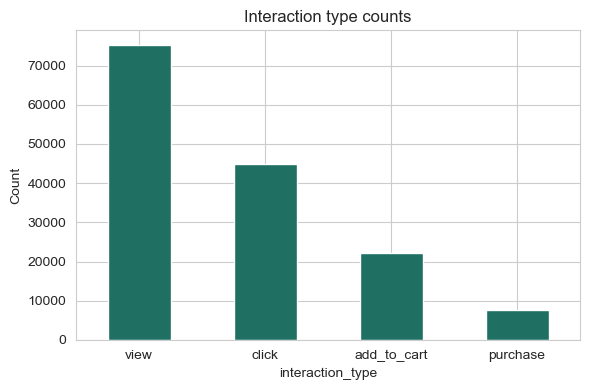

In [7]:
interaction_counts = df['interaction_type'].value_counts()
print(interaction_counts)

overall_purchase_rate = df['purchase'].mean()
print(f"\nOverall purchase rate: {overall_purchase_rate:.4f} ({overall_purchase_rate*100:.2f}%)")

fig, ax = plt.subplots(figsize=(6,4))
interaction_counts.plot(kind='bar', ax=ax, color='#1F6F63')
ax.set_title('Interaction type counts')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# 2.2 Users, products, categories, brands — basic cardinality

In [8]:
print("Unique users:", df['user_id'].nunique())
print("Unique products:", df['product_id'].nunique())
print("Categories:", df['product_category'].unique())
print("Brands:", df['brand'].unique())
print("Devices:", df['device_type'].unique())

Unique users: 4999
Unique products: 1999
Categories: ['Beauty' 'Electronics' 'Apparel' 'Home' 'Sports']
Brands: ['Apple' 'LG' 'Puma' 'Nike' 'Samsung' 'Adidas' 'Sony']
Devices: ['mobile' 'tablet' 'desktop']


In [10]:
# 3. Key finding — `user_id` / `product_id` are not stable entities
# Before building any model, it's worth checking a basic assumption that most recommendation
# approaches rely on: that a given `user_id` represents one consistent person, and a given
# `product_id` represents one consistent product. We test that directly below.

In [11]:
# For a sample of product_ids, how many distinct categories/brands does each one appear under?
sample_products = df['product_id'].drop_duplicates().sample(10, random_state=42)

for pid in sample_products:
    rows = df[df['product_id'] == pid]
    print(f"{pid}: {rows['product_category'].nunique()} categories, "
          f"{rows['brand'].nunique()} brands, "
          f"price range {rows['price'].min():.2f}-{rows['price'].max():.2f}")

P0355: 5 categories, 7 brands, price range 5.74-498.77
P1840: 5 categories, 7 brands, price range 13.11-498.04
P0070: 5 categories, 7 brands, price range 16.86-492.89
P1875: 5 categories, 7 brands, price range 5.05-499.84
P1542: 5 categories, 7 brands, price range 6.40-497.67
P1466: 5 categories, 7 brands, price range 12.42-495.51
P0954: 5 categories, 7 brands, price range 10.10-496.43
P1368: 5 categories, 7 brands, price range 13.22-499.16
P0228: 5 categories, 7 brands, price range 6.50-499.78
P0477: 5 categories, 7 brands, price range 7.87-490.76


In [12]:
# Across ALL products: how many categories/brands does the average product_id appear under?
per_product = df.groupby('product_id').agg(
    n_categories=('product_category', 'nunique'),
    n_brands=('brand', 'nunique')
)
print(per_product.describe())

       n_categories  n_brands
count        1999.0    1999.0
mean            5.0       7.0
std             0.0       0.0
min             5.0       7.0
25%             5.0       7.0
50%             5.0       7.0
75%             5.0       7.0
max             5.0       7.0


In [13]:
# Same check for user_id: does it map to a stable age / loyalty score?
sample_users = df['user_id'].drop_duplicates().sample(10, random_state=42)

for uid in sample_users:
    rows = df[df['user_id'] == uid]
    print(f"{uid}: age range {rows['user_age'].min()}-{rows['user_age'].max()}, "
          f"loyalty_score range {rows['loyalty_score'].min()}-{rows['loyalty_score'].max()}")

U2569: age range 21-64, loyalty_score range 0-98
U3787: age range 26-57, loyalty_score range 12-91
U1259: age range 19-63, loyalty_score range 4-99
U4668: age range 18-63, loyalty_score range 6-97
U4044: age range 18-63, loyalty_score range 7-99
U1211: age range 19-62, loyalty_score range 6-97
U1637: age range 18-64, loyalty_score range 2-92
U3346: age range 20-64, loyalty_score range 3-96
U0440: age range 19-64, loyalty_score range 1-100
U2738: age range 18-63, loyalty_score range 13-99


In [14]:
per_user = df.groupby('user_id').agg(
    n_distinct_ages=('user_age', 'nunique'),
    n_distinct_loyalty=('loyalty_score', 'nunique')
)
print(per_user.describe())

       n_distinct_ages  n_distinct_loyalty
count      4999.000000         4999.000000
mean         22.175635           25.931586
std           3.397849            4.382306
min          11.000000           11.000000
25%          20.000000           23.000000
50%          22.000000           26.000000
75%          24.000000           29.000000
max          34.000000           41.000000


In [15]:
# 4. Correlation analysis — does anything predict `purchase`?

In [16]:
numeric_cols = ['price', 'discount', 'user_age', 'loyalty_score',
                 'previous_purchase_count', 'avg_purchase_value', 'rating']

corr_with_purchase = df[numeric_cols + ['purchase']].corr()['purchase'].drop('purchase')
corr_with_purchase.sort_values(key=abs, ascending=False)

previous_purchase_count   -0.002921
user_age                   0.002701
avg_purchase_value         0.002490
discount                  -0.001935
loyalty_score             -0.001684
price                     -0.001334
rating                    -0.001083
Name: purchase, dtype: float64

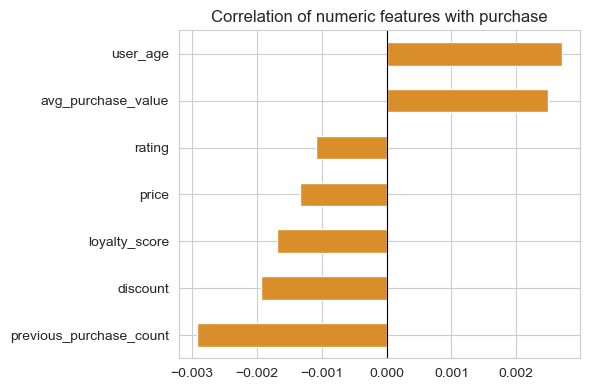

In [17]:
fig, ax = plt.subplots(figsize=(6,4))
corr_with_purchase.sort_values().plot(kind='barh', ax=ax, color='#D98E2B')
ax.set_title('Correlation of numeric features with purchase')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [18]:
# Purchase rate by category, brand, device, location, gender
for col in ['product_category', 'brand', 'device_type', 'location', 'user_gender']:
    rates = df.groupby(col)['purchase'].mean().sort_values(ascending=False)
    print(f"\n--- Purchase rate by {col} ---")
    print(rates)


--- Purchase rate by product_category ---
product_category
Electronics    0.051717
Beauty         0.050784
Apparel        0.050198
Home           0.050180
Sports         0.049751
Name: purchase, dtype: float64

--- Purchase rate by brand ---
brand
Adidas     0.052236
LG         0.052126
Nike       0.050712
Sony       0.050595
Samsung    0.050191
Puma       0.049540
Apple      0.048289
Name: purchase, dtype: float64

--- Purchase rate by device_type ---
device_type
tablet     0.051776
desktop    0.051610
mobile     0.049775
Name: purchase, dtype: float64

--- Purchase rate by location ---
location
Chicago        0.051674
Los Angeles    0.051397
Miami          0.051131
New York       0.050124
Houston        0.048296
Name: purchase, dtype: float64

--- Purchase rate by user_gender ---
user_gender
Other     0.051188
Male      0.051031
Female    0.049964
Name: purchase, dtype: float64


In [20]:
## 5. Preprocessing

# Two columns are deliberately **excluded** as model features:
# - `interaction_type` — this is label leakage: `purchase == 1` if and only if
#   `interaction_type == 'purchase'`, a 1:1 relationship, confirmed below.
# - `rating` — only present for a subset of interactions and not something known
#   *before* a purchase decision, so including it would also leak information.

In [21]:
# Confirm the leakage relationship before excluding interaction_type
pd.crosstab(df['interaction_type'], df['purchase'])

purchase,0,1
interaction_type,,
add_to_cart,22217,0
click,44989,0
purchase,0,7579
view,75215,0


In [22]:
feature_cols_numeric = ['price', 'discount', 'user_age', 'loyalty_score',
                         'previous_purchase_count', 'avg_purchase_value']
feature_cols_categorical = ['product_category', 'brand', 'device_type',
                             'location', 'user_gender']

X = df[feature_cols_numeric + feature_cols_categorical]
y = df['purchase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train purchase rate:", y_train.mean().round(4))
print("Test purchase rate:", y_test.mean().round(4))

Train shape: (120000, 11)  Test shape: (30000, 11)
Train purchase rate: 0.0505
Test purchase rate: 0.0505


In [23]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), feature_cols_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols_categorical)
])

In [25]:
## 6. Model — `RandomForestClassifier`

# Class-balanced, 200 trees, wrapped in a pipeline with the preprocessing step above so the same
# transform is applied consistently at inference time.

In [26]:
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

model.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
## 7. Evaluation — reported honestly

# Accuracy alone is misleading here: since only ~5% of rows are purchases, a model that always
# predicts "no purchase" would already score ~95% accuracy while being useless. Precision, recall,
# F1, and ROC-AUC are reported alongside accuracy for exactly this reason.

In [28]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

majority_baseline = max(y_test.mean(), 1 - y_test.mean())

print(f"Accuracy:              {acc:.4f}")
print(f"Precision:             {prec:.4f}")
print(f"Recall:                {rec:.4f}")
print(f"F1 score:               {f1:.4f}")
print(f"ROC-AUC:                {roc_auc:.4f}")
print(f"Majority-class baseline accuracy: {majority_baseline:.4f}")

Accuracy:              0.9495
Precision:             0.0000
Recall:                0.0000
F1 score:               0.0000
ROC-AUC:                0.5035
Majority-class baseline accuracy: 0.9495


C:\Users\Basineni Neeraj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Basineni Neeraj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Basineni Neeraj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

              precision    recall  f1-score   support

 No purchase       0.95      1.00      0.97     28484
    Purchase       0.00      0.00      0.00      1516

    accuracy                           0.95     30000
   macro avg       0.47      0.50      0.49     30000
weighted avg       0.90      0.95      0.92     30000



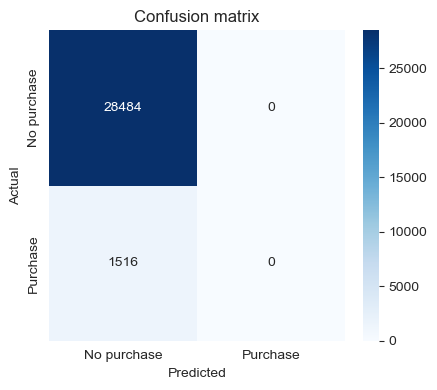

In [29]:
print(classification_report(y_test, y_pred, target_names=['No purchase', 'Purchase']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No purchase', 'Purchase'],
            yticklabels=['No purchase', 'Purchase'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion matrix')
plt.tight_layout()
plt.show()

C:\Users\Basineni Neeraj\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


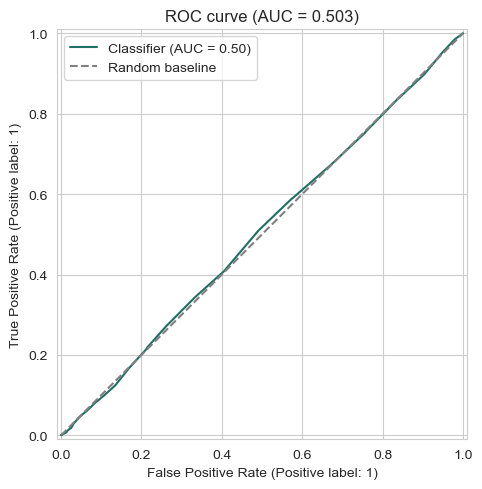

In [30]:
fig, ax = plt.subplots(figsize=(5,5))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, color='#1F6F63')
ax.plot([0,1],[0,1], linestyle='--', color='grey', label='Random baseline')
ax.set_title(f'ROC curve (AUC = {roc_auc:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
# 8. (Optional) Save the trained model

In [32]:
import joblib
joblib.dump(model, 'model.joblib')
print("Saved to model.joblib")

Saved to model.joblib
